# Mini Project: Neural Network on MNIST

## Goal
Build and understand a simple neural network for digit classification using the MNIST dataset.

We will:
- prepare image data for a neural network
- build a simple MLP (Multi-Layer Perceptron)
- train and evaluate the model
- analyze training behavior and stability

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


## Dataset

We use the MNIST dataset:
- 60,000 training images
- grayscale images of size 28 × 28
- labels from 0 to 9

Each sample has shape:
- image: (1, 28, 28)
- label: integer in [0, 9]

This is our input `X`.

In [ ]:
# Define a transform to convert the images to tensors
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

In [ ]:
# Check the length of the dataset and the shape of the first image and label
print(len(train_dataset))  # should be 60000

image, label = train_dataset[0]

print(image.shape)  # (1, 28, 28)
print(label)        # 0–9

60000
torch.Size([1, 28, 28])
5


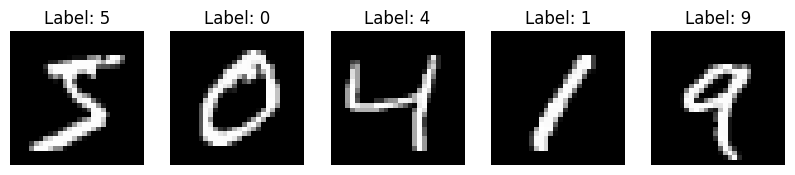

In [ ]:
# Visualize the first 5 images and their labels
fig, ax = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    img, lbl = train_dataset[i]
    ax[i].imshow(img.squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {lbl}")
    ax[i].axis("off")

plt.show()

## DataLoader

The DataLoader feeds the model with mini-batches.

Batch shape:
- images: (batch_size, 1, 28, 28)
- labels: (batch_size)

We use batching to:
- make training efficient
- stabilize gradient updates

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
# Inspect one batch of data
images, labels = next(iter(train_loader))

print(images.shape)  # (32, 1, 28, 28)
print(labels.shape)  # (32,)

torch.Size([32, 1, 28, 28])
torch.Size([32])


## Flattening Images

Neural networks expect vectors, not 2D images.

We convert:
(1, 28, 28) → (784)

So each image becomes a vector of 784 features.

In [ ]:
# Flatten while keeping batch dimension
images_flat = images.view(images.size(0), -1) 

print(images_flat.shape)  # (32, 784)

# manual flatten just for understanding — model already handles it

torch.Size([32, 784])


### Why flattening is needed

Fully connected layers expect 1D vectors, not 2D images.

Flattening converts spatial information into a feature vector:
(1, 28, 28) → (784)

However, this also means:
→ the model loses spatial structure (neighboring pixels relationship)

This is why CNNs are usually preferred for images.

## Model: Simple MLP

Architecture:
- Flatten → Linear(784 → 128) → ReLU → Linear(128 → 10)

Important:
- ReLU introduces non-linearity
- Without it, the model would behave like a single linear layer
- Output is **logits**, not probabilities

In [ ]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),               # no need to flatten manually
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)           # final output size is 10 because digits are 0-9
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### Model capacity

This model has limited capacity:
- only one hidden layer
- 128 neurons

It is powerful enough for MNIST,
but would struggle on more complex datasets.

Increasing depth or width increases capacity,
but also increases risk of overfitting.

In [ ]:
# Move the batch of images and labels to the device
images, labels = next(iter(train_loader))

print("images shape before sending to device:", images.shape)
print("labels shape before sending to device:", labels.shape)

images = images.to(device)
labels = labels.to(device)

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("first 10 labels:", labels[:10])

images shape before sending to device: torch.Size([32, 1, 28, 28])
labels shape before sending to device: torch.Size([32])
images shape: torch.Size([32, 1, 28, 28])
labels shape: torch.Size([32])
first 10 labels: tensor([2, 3, 6, 3, 9, 7, 7, 5, 2, 7], device='mps:0')


## Forward Pass

The model outputs logits of shape:
(batch_size, 10)

Each value represents a score for a digit class.

In [ ]:
# Forward pass: compute predictions
outputs = model(images)

print("output shape:", outputs.shape)
print(outputs[:2])

output shape: torch.Size([32, 10])
tensor([[-0.0970, -0.0829,  0.0403, -0.1613, -0.0216,  0.0966, -0.0724, -0.0755,
         -0.0556,  0.0337],
        [-0.1401, -0.2237,  0.2071, -0.1929, -0.1501, -0.0089, -0.0621, -0.1534,
         -0.0220, -0.1216]], device='mps:0', grad_fn=<SliceBackward0>)


In [ ]:
# The output is raw scores (logits) for each class. To get predicted classes, we take the argmax.
preds = torch.argmax(outputs, dim=1)

print("predicted classes:", preds[:10])
print("true labels:      ", labels[:10])

predicted classes: tensor([5, 2, 2, 2, 5, 2, 2, 2, 2, 2], device='mps:0')
true labels:       tensor([2, 3, 6, 3, 9, 7, 7, 5, 2, 7], device='mps:0')


### Logits vs probabilities

The model outputs raw scores (logits), not probabilities.

Why?
- logits are numerically more stable
- CrossEntropyLoss applies softmax internally

Applying softmax twice would lead to incorrect training.

## Loss Function

We use CrossEntropyLoss for classification.

Important:
- Input: raw logits (NO softmax)
- Target: integer class labels

PyTorch applies softmax internally.

In [ ]:
# Compute the loss using CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)

print("loss:", loss.item())

loss: 2.309201955795288


### What the loss represents

Cross-entropy measures how far predictions are from the true labels.

- low loss → correct and confident predictions
- high loss → incorrect or uncertain predictions

Minimizing loss means improving both:
- accuracy
- confidence

## From Logits to Probabilities

We apply softmax to interpret outputs as probabilities.

The predicted class is the index with highest probability.

In [ ]:
# To get probabilities, we can apply softmax to the outputs
probs = torch.softmax(outputs, dim=1)

print("probabilities for first image:")
print(probs[0])
print("sum:", probs[0].sum().item())
print("predicted class:", torch.argmax(probs[0]).item())
print("true label:", labels[0].item())

probabilities for first image:
tensor([0.0942, 0.0955, 0.1080, 0.0883, 0.1015, 0.1143, 0.0965, 0.0962, 0.0981,
        0.1073], device='mps:0', grad_fn=<SelectBackward0>)
sum: 0.9999999403953552
predicted class: 5
true label: 2


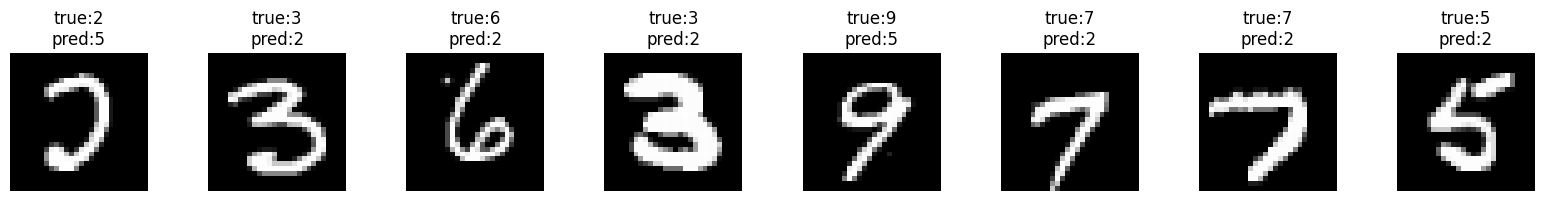

In [ ]:
# Visualize the first 8 images, their true labels, and predicted labels
import matplotlib.pyplot as plt

images_cpu = images[:8].cpu()
labels_cpu = labels[:8].cpu()
preds_cpu = preds[:8].cpu()

fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i, ax in enumerate(axes):
    ax.imshow(images_cpu[i].squeeze(), cmap="gray")
    ax.set_title(f"true:{labels_cpu[i].item()}\npred:{preds_cpu[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Set up the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Training Loop (1 Epoch)

Each iteration:
1. Forward pass
2. Compute loss
3. Backpropagation
4. Update weights

We also track:
- loss
- accuracy

In [17]:
# Move model to GPU (or CPU if no GPU available)
model.to(device)

# Set model to training mode (important for layers like dropout or batchnorm later)
model.train()

# Initialize tracking variables
running_loss = 0.0   # accumulate loss over all batches
correct = 0          # count correct predictions
total = 0            # count total samples

printed_grads = False # set to True to print gradients

# Loop over batches of data
for images, labels in train_loader:

    # Move data to same device as model
    images = images.to(device)
    labels = labels.to(device)

    # Reset gradients from previous step (PyTorch accumulates gradients by default)
    optimizer.zero_grad()

    # FORWARD PASS: input -> model -> predictions (logits)
    logits = model(images)

    # Compute loss between predictions and true labels
    loss = criterion(logits, labels)

    # BACKWARD PASS: compute gradients of loss w.r.t ALL model parameters
    loss.backward()

    # print gradients
    if not printed_grads:
        print("Gradients after loss.backward():")
        for name, param in model.named_parameters():
            if param.grad is not None:
                print(name, param.grad.shape, param.grad.norm().item())
        printed_grads = True

    # UPDATE STEP: use gradients to update weights (gradient descent step)
    optimizer.step()

    # Accumulate loss (convert tensor to Python float)
    running_loss += loss.item()

    # Get predicted class (highest logit)
    preds = logits.argmax(dim=1)

    # Count how many predictions are correct
    correct += (preds == labels).sum().item()

    # Count total number of samples processed
    total += labels.size(0)


# Average loss over all batches
epoch_loss = running_loss / len(train_loader)

# Compute accuracy over all samples
epoch_acc = correct / total

# Print results
print(f"Epoch loss: {epoch_loss:.4f}")
print(f"Epoch accuracy: {epoch_acc:.4f}")

Gradients after loss.backward():
1.weight torch.Size([128, 784]) 0.9390946626663208
1.bias torch.Size([128]) 0.09930206835269928
3.weight torch.Size([10, 128]) 0.37357276678085327
3.bias torch.Size([10]) 0.23043985664844513
Epoch loss: 0.2916
Epoch accuracy: 0.9174


### Why we reset gradients

PyTorch accumulates gradients by default.

If we don’t reset them:
→ gradients from previous batches would accumulate
→ updates would become incorrect

This is why we call:
`optimizer.zero_grad()`

## Effect of ReLU

ReLU keeps positive values and sets negative values to zero.

This introduces non-linearity and allows the model to learn complex patterns.

In [ ]:
# Inspect the activations after the first linear layer and ReLU
images, labels = next(iter(train_loader))
images = images.to(device)

z1 = model[1](model[0](images)) # linear output
a1 = model[2](z1)               # after ReLU

print("z1 min/max:", z1.min().item(), z1.max().item())
print("a1 min/max:", a1.min().item(), a1.max().item())

z1 min/max: -13.94460391998291 8.597832679748535
a1 min/max: 0.0 8.597832679748535


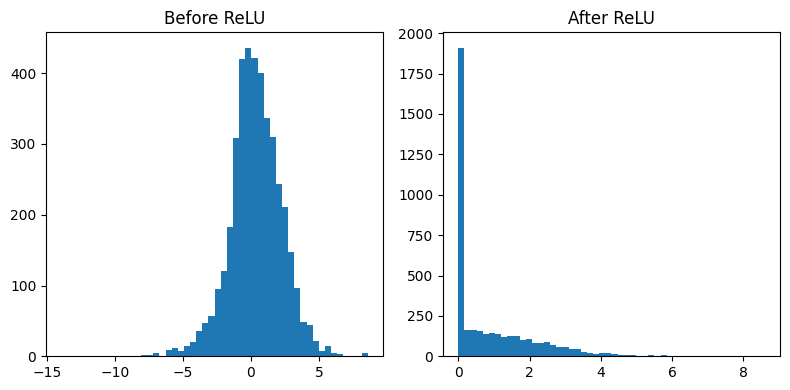

In [ ]:
# Visualize the distribution of activations before and after ReLU
f, ax = plt.subplots(1, 2, figsize=(8,4))

ax[0].hist(z1.detach().cpu().numpy().ravel(), bins=50)
ax[0].set_title("Before ReLU")

ax[1].hist(a1.detach().cpu().numpy().ravel(), bins=50)
ax[1].set_title("After ReLU")

plt.tight_layout()
plt.show()

## Model Without ReLU

Removing ReLU makes the model purely linear.

Result:
- worse performance
- cannot capture complex patterns

In [ ]:
# Now let's see what happens if we remove the ReLU activation
model_no_relu = nn.Sequential(
    nn.Flatten(),               # no need to flatten manually
    nn.Linear(28 * 28, 128),
    # nn.ReLU(), # REMOVED
    nn.Linear(128, 10)           # final output size is 10 because digits are 0-9
).to(device)

print(model_no_relu)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# Set up the optimizer for the model without ReLU
optimizer_no_relu = torch.optim.Adam(model_no_relu.parameters(), lr=1e-3)

In [ ]:
# Train the model without ReLU for one epoch and compare loss and accuracy
model_no_relu.train()

running_loss_no_relu = 0.0
correct_no_relu = 0
total_no_relu = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer_no_relu.zero_grad()
    logits = model_no_relu(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer_no_relu.step()

    running_loss_no_relu += loss.item()
    preds = logits.argmax(dim=1)
    correct_no_relu += (preds == labels).sum().item()
    total_no_relu += labels.size(0)

epoch_loss_no_relu = running_loss_no_relu / len(train_loader)
epoch_acc_no_relu = correct_no_relu / total_no_relu

print(f"No ReLU - loss: {epoch_loss_no_relu:.4f}")
print(f"No ReLU - accuracy: {epoch_acc_no_relu:.4f}")

No ReLU - loss: 0.3636
No ReLU - accuracy: 0.8978


In [ ]:
# Compare the results with and without ReLU
print(f"With ReLU    - loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
print(f"Without ReLU - loss: {epoch_loss_no_relu:.4f}, acc: {epoch_acc_no_relu:.4f}")

With ReLU    - loss: 0.2916, acc: 0.9174
Without ReLU - loss: 0.3636, acc: 0.8978


## Training Over Multiple Epochs

We train for multiple epochs and track:
- training loss
- training accuracy

This helps visualize learning dynamics.

In [ ]:
# Fresh model definition for further experiments
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training loop for multiple epochs
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

Epoch 1/10 - loss: 0.2954 - acc: 0.9181
Epoch 2/10 - loss: 0.1269 - acc: 0.9630
Epoch 3/10 - loss: 0.0851 - acc: 0.9744
Epoch 4/10 - loss: 0.0631 - acc: 0.9810
Epoch 5/10 - loss: 0.0485 - acc: 0.9852
Epoch 6/10 - loss: 0.0376 - acc: 0.9882
Epoch 7/10 - loss: 0.0307 - acc: 0.9904
Epoch 8/10 - loss: 0.0250 - acc: 0.9923
Epoch 9/10 - loss: 0.0196 - acc: 0.9940
Epoch 10/10 - loss: 0.0171 - acc: 0.9948


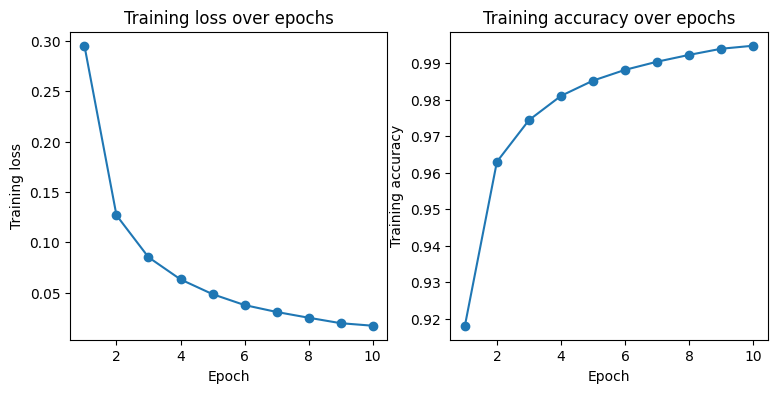

In [ ]:
# Visualize training loss and accuracy over epochs
f, ax = plt.subplots(1, 2, figsize=(9, 4))

ax[0].plot(range(1, num_epochs + 1), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training loss")
ax[0].set_title("Training loss over epochs")

ax[1].plot(range(1, num_epochs + 1), train_accuracies, marker="o")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training accuracy")
ax[1].set_title("Training accuracy over epochs")

plt.show()

### Training behavior

- Loss decreases over epochs → the model is learning
- Accuracy increases → predictions improve

The fast improvement in early epochs shows:
→ gradient descent quickly finds useful patterns

The plateau indicates:
→ the model is approaching convergence

## Train / Validation Split

We split data into:
- training set (80%)
- validation set (20%)

Purpose:
- training → learn parameters
- validation → evaluate generalization

In [ ]:
# Split the dataset into a training set and a validation set
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Why validation matters

Training performance alone is misleading.

A model can:
- perform very well on training data
- but fail on unseen data

Validation helps detect:
→ overfitting
→ generalization ability

In [ ]:
# Fresh model again for training with validation
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training loop for multiple epochs with validation
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    
    # Training loop
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation loop
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # disable gradients (we don't train on the validation set)
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # We just do a forward pass and compute the loss and accuracy
            logits = model(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    print(f"Epoch {epoch+1}/{num_epochs} "
      f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
      f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Epoch 1/10 - train loss: 0.3245, acc: 0.9099 - val loss: 0.1813, acc: 0.9476
Epoch 2/10 - train loss: 0.1445, acc: 0.9580 - val loss: 0.1267, acc: 0.9629
Epoch 3/10 - train loss: 0.0980, acc: 0.9716 - val loss: 0.1062, acc: 0.9663
Epoch 4/10 - train loss: 0.0738, acc: 0.9769 - val loss: 0.0998, acc: 0.9696
Epoch 5/10 - train loss: 0.0565, acc: 0.9836 - val loss: 0.0888, acc: 0.9728
Epoch 6/10 - train loss: 0.0440, acc: 0.9863 - val loss: 0.0895, acc: 0.9722
Epoch 7/10 - train loss: 0.0355, acc: 0.9891 - val loss: 0.0892, acc: 0.9745
Epoch 8/10 - train loss: 0.0275, acc: 0.9920 - val loss: 0.0843, acc: 0.9760
Epoch 9/10 - train loss: 0.0220, acc: 0.9938 - val loss: 0.1003, acc: 0.9723
Epoch 10/10 - train loss: 0.0177, acc: 0.9948 - val loss: 0.0979, acc: 0.9747


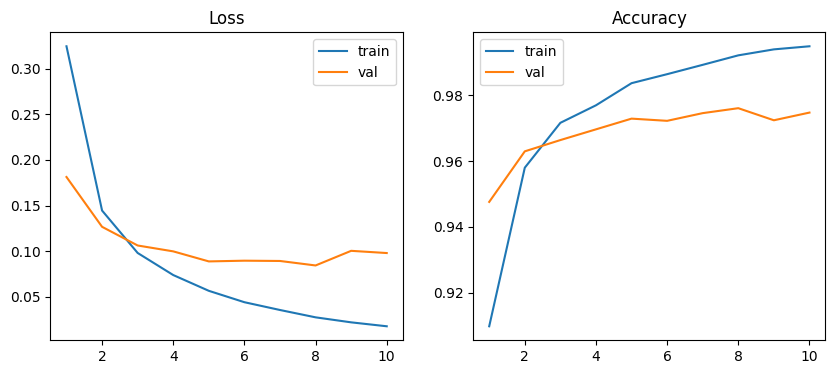

In [ ]:
# Visualize training and validation loss and accuracy over epochs
f, ax = plt.subplots(1, 2, figsize=(10, 4))

# Loss
ax[0].plot(range(1, num_epochs + 1), train_losses, label="train", color='tab:blue')
ax[0].plot(range(1, num_epochs + 1), val_losses, label="val", color='tab:orange')
ax[0].set_title("Loss")
ax[0].legend()

# Accuracy
ax[1].plot(range(1, num_epochs + 1), train_accuracies, label="train", color='tab:blue')
ax[1].plot(range(1, num_epochs + 1), val_accuracies, label="val", color='tab:orange')
ax[1].set_title("Accuracy")
ax[1].legend()

plt.show()

### Overfitting

We observe:
- training performance keeps improving
- validation performance plateaus

This means:
→ the model starts memorizing training data: overfitting

Solution:
- early stopping
- regularization (dropout, weight decay)

## Dropout Regularization

Dropout randomly disables neurons during training.

Effect:
- harder training
- better generalization
- reduced overfitting

In [ ]:
# Now let's add dropout to the model and see how it affects training
model_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(p=0.5), # strong dropout rate to see effect clearly
    nn.Linear(128, 10)
).to(device)

print(model_dropout)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# Set up the criterion and optimizer for the model with dropout
criterion = nn.CrossEntropyLoss()
optimizer_dropout = torch.optim.Adam(model_dropout.parameters(), lr=1e-3)

In [ ]:
# Training loop for multiple epochs with dropout
num_epochs = 10

train_losses_dropout = []
train_accuracies_dropout = []
val_losses_dropout = []
val_accuracies_dropout = []

for epoch in range(num_epochs):

    # Training
    model_dropout.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_dropout.zero_grad()
        logits = model_dropout(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_dropout.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses_dropout.append(epoch_loss)
    train_accuracies_dropout.append(epoch_acc)

    # Validation
    model_dropout.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model_dropout(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses_dropout.append(val_loss)
    val_accuracies_dropout.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
        f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

Epoch 1/10 - train loss: 0.4390, acc: 0.8731 - val loss: 0.1963, acc: 0.9440
Epoch 2/10 - train loss: 0.2456, acc: 0.9276 - val loss: 0.1479, acc: 0.9571
Epoch 3/10 - train loss: 0.1963, acc: 0.9426 - val loss: 0.1281, acc: 0.9610
Epoch 4/10 - train loss: 0.1780, acc: 0.9478 - val loss: 0.1123, acc: 0.9662
Epoch 5/10 - train loss: 0.1603, acc: 0.9514 - val loss: 0.1028, acc: 0.9680
Epoch 6/10 - train loss: 0.1502, acc: 0.9542 - val loss: 0.1008, acc: 0.9692
Epoch 7/10 - train loss: 0.1372, acc: 0.9584 - val loss: 0.0973, acc: 0.9701
Epoch 8/10 - train loss: 0.1306, acc: 0.9591 - val loss: 0.0965, acc: 0.9712
Epoch 9/10 - train loss: 0.1234, acc: 0.9621 - val loss: 0.0896, acc: 0.9739
Epoch 10/10 - train loss: 0.1209, acc: 0.9628 - val loss: 0.0936, acc: 0.9723


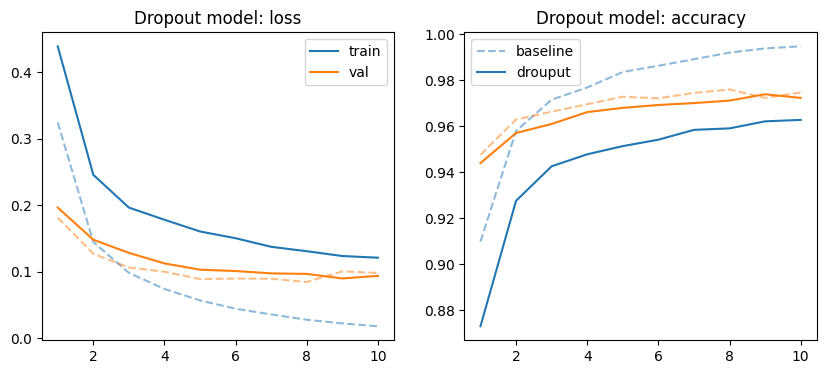

In [ ]:
# Visualize training and validation loss and accuracy over epochs for both models
f, ax = plt.subplots(1, 2, figsize=(10, 4))

# Loss
ax[0].plot(range(1, num_epochs + 1), train_losses, color='tab:blue', ls='dashed', alpha=0.5)
ax[0].plot(range(1, num_epochs + 1), val_losses, color='tab:orange', ls='dashed', alpha=0.5)

ax[0].plot(range(1, num_epochs + 1), train_losses_dropout, color='tab:blue', label="train")
ax[0].plot(range(1, num_epochs + 1), val_losses_dropout, color='tab:orange', label="val")

ax[0].set_title("Dropout model: loss")
ax[0].legend()

# Accuracy
ax[1].plot(range(1, num_epochs + 1), train_accuracies, label='baseline', color='tab:blue', ls='dashed', alpha=0.5)
ax[1].plot(range(1, num_epochs + 1), val_accuracies, color='tab:orange', ls='dashed', alpha=0.5)

ax[1].plot(range(1, num_epochs + 1), train_accuracies_dropout, label="drouput", color='tab:blue')
ax[1].plot(range(1, num_epochs + 1), val_accuracies_dropout, color='tab:orange')

ax[1].set_title("Dropout model: accuracy")
ax[1].legend()

plt.show()

### Effect of dropout

Dropout introduces noise during training:
- randomly disables neurons

This forces the model to:
→ learn more robust features
→ avoid relying on specific neurons

Result:
- slightly harder training
- better generalization

## L2 Regularization (Weight Decay)

Adds a penalty on large weights.

Effect:
- smoother model
- reduces overfitting

In [ ]:
# Let's also try L2 regularization (weight decay) and see how it compares to dropout
model_l2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [ ]:
# Set up the criterion and optimizer for the model with L2 regularization
criterion = nn.CrossEntropyLoss()
optimizer_l2 = torch.optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-3) # L2 is added through the optimizer

In [ ]:
# Training loop for multiple epochs with L2 regularization
num_epochs = 10

train_losses_l2 = []
train_accuracies_l2 = []
val_losses_l2 = []
val_accuracies_l2 = []

for epoch in range(num_epochs):

    # Training
    model_l2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_l2.zero_grad()
        logits = model_l2(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_l2.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses_l2.append(epoch_loss)
    train_accuracies_l2.append(epoch_acc)

    # Validation
    model_l2.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model_l2(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses_l2.append(val_loss)
    val_accuracies_l2.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
        f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

Epoch 1/10 - train loss: 0.3421, acc: 0.9068 - val loss: 0.1978, acc: 0.9453
Epoch 2/10 - train loss: 0.1709, acc: 0.9520 - val loss: 0.1584, acc: 0.9559
Epoch 3/10 - train loss: 0.1343, acc: 0.9620 - val loss: 0.1406, acc: 0.9585
Epoch 4/10 - train loss: 0.1181, acc: 0.9668 - val loss: 0.1174, acc: 0.9654
Epoch 5/10 - train loss: 0.1090, acc: 0.9698 - val loss: 0.1161, acc: 0.9676
Epoch 6/10 - train loss: 0.1008, acc: 0.9720 - val loss: 0.1138, acc: 0.9668
Epoch 7/10 - train loss: 0.0975, acc: 0.9732 - val loss: 0.1133, acc: 0.9658
Epoch 8/10 - train loss: 0.0949, acc: 0.9743 - val loss: 0.1115, acc: 0.9679
Epoch 9/10 - train loss: 0.0910, acc: 0.9754 - val loss: 0.1146, acc: 0.9666
Epoch 10/10 - train loss: 0.0909, acc: 0.9752 - val loss: 0.1044, acc: 0.9690


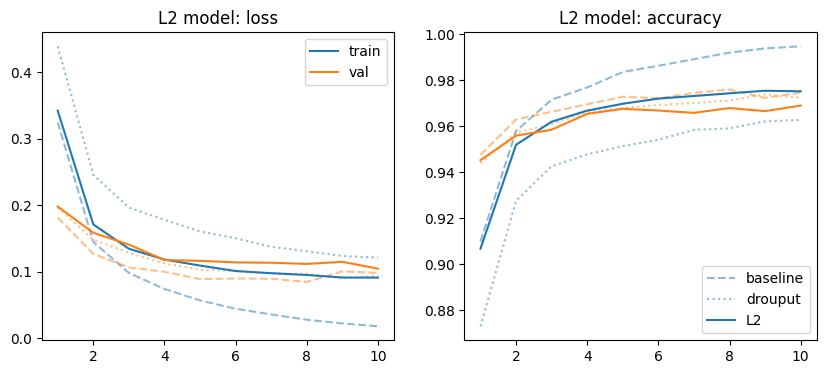

In [ ]:
# Visualize training and validation loss and accuracy over epochs for all three models
f, ax = plt.subplots(1, 2, figsize=(10, 4))

# Loss
ax[0].plot(range(1, num_epochs + 1), train_losses, color='tab:blue', ls='dashed', alpha=0.5)
ax[0].plot(range(1, num_epochs + 1), val_losses, color='tab:orange', ls='dashed', alpha=0.5)

ax[0].plot(range(1, num_epochs + 1), train_losses_dropout, color='tab:blue', ls='dotted', alpha=0.5)
ax[0].plot(range(1, num_epochs + 1), val_losses_dropout, color='tab:orange', ls='dotted', alpha=0.5)

ax[0].plot(range(1, num_epochs + 1), train_losses_l2, color='tab:blue', label="train")
ax[0].plot(range(1, num_epochs + 1), val_losses_l2, color='tab:orange', label="val")

ax[0].set_title("L2 model: loss")
ax[0].legend()

# Accuracy
ax[1].plot(range(1, num_epochs + 1), train_accuracies, label='baseline', color='tab:blue', ls='dashed', alpha=0.5)
ax[1].plot(range(1, num_epochs + 1), val_accuracies, color='tab:orange', ls='dashed', alpha=0.5)

ax[1].plot(range(1, num_epochs + 1), train_accuracies_dropout, label="drouput", color='tab:blue', ls='dotted', alpha=0.5)
ax[1].plot(range(1, num_epochs + 1), val_accuracies_dropout, color='tab:orange', ls='dotted', alpha=0.5)

ax[1].plot(range(1, num_epochs + 1), train_accuracies_l2, label="L2", color='tab:blue')
ax[1].plot(range(1, num_epochs + 1), val_accuracies_l2, color='tab:orange')

ax[1].set_title("L2 model: accuracy")
ax[1].legend()

plt.show()

### Effect of weight decay

L2 regularization penalizes large weights.

This encourages:
- smoother decision boundaries
- simpler models

Result:
→ reduced overfitting

## Optimizer Comparison

We compare:
- SGD
- SGD + Momentum
- Adam

Goal:
- compare convergence speed
- compare final performance

In [ ]:
def make_mlp(): # to avoid rewriting the model 3 times
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)

In [ ]:
# Define our training function
def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs=10):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"- train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f} "
            f"- val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )

    return {
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
    }

In [63]:
# SGD
model_sgd = make_mlp()
criterion = nn.CrossEntropyLoss()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.1)

results_sgd = train_model(
    model_sgd, optimizer_sgd, criterion, train_loader, val_loader, num_epochs=10
)

Epoch 1/10 - train loss: 0.3747, acc: 0.8957 - val loss: 0.2192, acc: 0.9367
Epoch 2/10 - train loss: 0.1800, acc: 0.9480 - val loss: 0.1517, acc: 0.9573
Epoch 3/10 - train loss: 0.1288, acc: 0.9637 - val loss: 0.1268, acc: 0.9636
Epoch 4/10 - train loss: 0.1016, acc: 0.9707 - val loss: 0.1160, acc: 0.9653
Epoch 5/10 - train loss: 0.0830, acc: 0.9763 - val loss: 0.1049, acc: 0.9690
Epoch 6/10 - train loss: 0.0688, acc: 0.9801 - val loss: 0.0933, acc: 0.9715
Epoch 7/10 - train loss: 0.0582, acc: 0.9832 - val loss: 0.0880, acc: 0.9730
Epoch 8/10 - train loss: 0.0498, acc: 0.9861 - val loss: 0.0876, acc: 0.9731
Epoch 9/10 - train loss: 0.0433, acc: 0.9884 - val loss: 0.0926, acc: 0.9715
Epoch 10/10 - train loss: 0.0376, acc: 0.9895 - val loss: 0.0821, acc: 0.9749


In [64]:
# SGD + Momentum
model_momentum = make_mlp()
criterion = nn.CrossEntropyLoss()
optimizer_momentum = torch.optim.SGD(model_momentum.parameters(), lr=0.1, momentum=0.9)

results_momentum = train_model(
    model_momentum, optimizer_momentum, criterion, train_loader, val_loader, num_epochs=10
)

Epoch 1/10 - train loss: 0.2950, acc: 0.9120 - val loss: 0.1910, acc: 0.9423
Epoch 2/10 - train loss: 0.1735, acc: 0.9499 - val loss: 0.1845, acc: 0.9497
Epoch 3/10 - train loss: 0.1423, acc: 0.9595 - val loss: 0.1890, acc: 0.9522
Epoch 4/10 - train loss: 0.1181, acc: 0.9666 - val loss: 0.1743, acc: 0.9586
Epoch 5/10 - train loss: 0.1117, acc: 0.9689 - val loss: 0.1542, acc: 0.9654
Epoch 6/10 - train loss: 0.0892, acc: 0.9749 - val loss: 0.2088, acc: 0.9588
Epoch 7/10 - train loss: 0.0892, acc: 0.9758 - val loss: 0.1632, acc: 0.9630
Epoch 8/10 - train loss: 0.0811, acc: 0.9781 - val loss: 0.1913, acc: 0.9655
Epoch 9/10 - train loss: 0.0751, acc: 0.9800 - val loss: 0.2081, acc: 0.9616
Epoch 10/10 - train loss: 0.0704, acc: 0.9808 - val loss: 0.1742, acc: 0.9701


In [65]:
# Adam
model_adam = make_mlp()
criterion = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=1e-3)

results_adam = train_model(
    model_adam, optimizer_adam, criterion, train_loader, val_loader, num_epochs=10
)

Epoch 1/10 - train loss: 0.3165, acc: 0.9128 - val loss: 0.1750, acc: 0.9484
Epoch 2/10 - train loss: 0.1412, acc: 0.9582 - val loss: 0.1263, acc: 0.9619
Epoch 3/10 - train loss: 0.0951, acc: 0.9716 - val loss: 0.1119, acc: 0.9648
Epoch 4/10 - train loss: 0.0703, acc: 0.9791 - val loss: 0.0932, acc: 0.9717
Epoch 5/10 - train loss: 0.0533, acc: 0.9841 - val loss: 0.0969, acc: 0.9715
Epoch 6/10 - train loss: 0.0421, acc: 0.9870 - val loss: 0.0908, acc: 0.9731
Epoch 7/10 - train loss: 0.0322, acc: 0.9903 - val loss: 0.0840, acc: 0.9744
Epoch 8/10 - train loss: 0.0271, acc: 0.9922 - val loss: 0.0878, acc: 0.9752
Epoch 9/10 - train loss: 0.0222, acc: 0.9933 - val loss: 0.0886, acc: 0.9756
Epoch 10/10 - train loss: 0.0173, acc: 0.9951 - val loss: 0.0949, acc: 0.9742


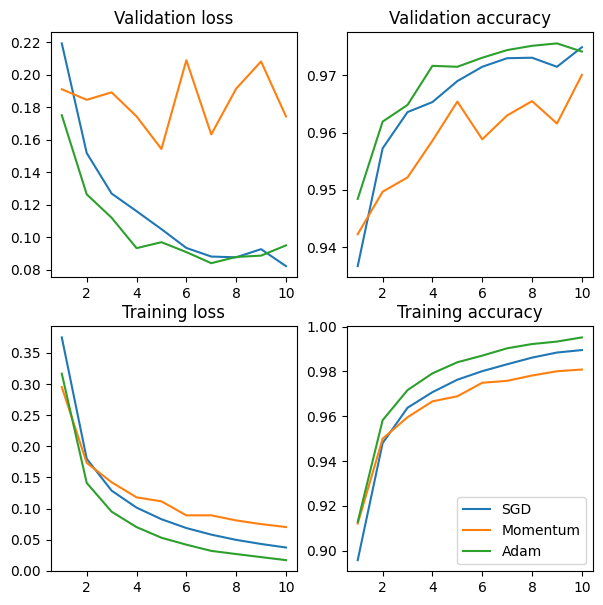

In [ ]:
# Visualize training and validation loss and accuracy over epochs
epochs = range(1, 11)

f, ax = plt.subplots(2, 2, figsize=(7, 7))

# Validation loss
ax[0,0].plot(epochs, results_sgd["val_losses"], label="SGD")
ax[0,0].plot(epochs, results_momentum["val_losses"], label="Momentum")
ax[0,0].plot(epochs, results_adam["val_losses"], label="Adam")
ax[0,0].set_title("Validation loss")

# Validation accuracy
ax[0,1].plot(epochs, results_sgd["val_accuracies"], label="SGD")
ax[0,1].plot(epochs, results_momentum["val_accuracies"], label="Momentum")
ax[0,1].plot(epochs, results_adam["val_accuracies"], label="Adam")
ax[0,1].set_title("Validation accuracy")

# Training loss
ax[1,0].plot(epochs, results_sgd["train_losses"], label="SGD")
ax[1,0].plot(epochs, results_momentum["train_losses"], label="Momentum")
ax[1,0].plot(epochs, results_adam["train_losses"], label="Adam")
ax[1,0].set_title("Training loss")

# Training accuracy
ax[1,1].plot(epochs, results_sgd["train_accuracies"], label="SGD")
ax[1,1].plot(epochs, results_momentum["train_accuracies"], label="Momentum")
ax[1,1].plot(epochs, results_adam["train_accuracies"], label="Adam")
ax[1,1].set_title("Training accuracy")
ax[1,1].legend()

plt.show()

In [73]:
# SGD + Momentum with lower LR
model_momentum_lower_lr = make_mlp()
criterion = nn.CrossEntropyLoss()
optimizer_momentum_lower_lr = torch.optim.SGD(model_momentum_lower_lr.parameters(), lr=0.05, momentum=0.9)

results_momentum_lower_lr = train_model(
    model_momentum_lower_lr, optimizer_momentum_lower_lr, criterion, train_loader, val_loader, num_epochs=10
)

Epoch 1/10 - train loss: 0.2526, acc: 0.9227 - val loss: 0.1497, acc: 0.9557
Epoch 2/10 - train loss: 0.1120, acc: 0.9652 - val loss: 0.1277, acc: 0.9629
Epoch 3/10 - train loss: 0.0810, acc: 0.9749 - val loss: 0.1141, acc: 0.9695
Epoch 4/10 - train loss: 0.0641, acc: 0.9794 - val loss: 0.1088, acc: 0.9702
Epoch 5/10 - train loss: 0.0535, acc: 0.9831 - val loss: 0.1167, acc: 0.9680
Epoch 6/10 - train loss: 0.0388, acc: 0.9874 - val loss: 0.0995, acc: 0.9744
Epoch 7/10 - train loss: 0.0298, acc: 0.9905 - val loss: 0.1078, acc: 0.9739
Epoch 8/10 - train loss: 0.0270, acc: 0.9912 - val loss: 0.1097, acc: 0.9744
Epoch 9/10 - train loss: 0.0180, acc: 0.9941 - val loss: 0.1040, acc: 0.9752
Epoch 10/10 - train loss: 0.0152, acc: 0.9950 - val loss: 0.1046, acc: 0.9759


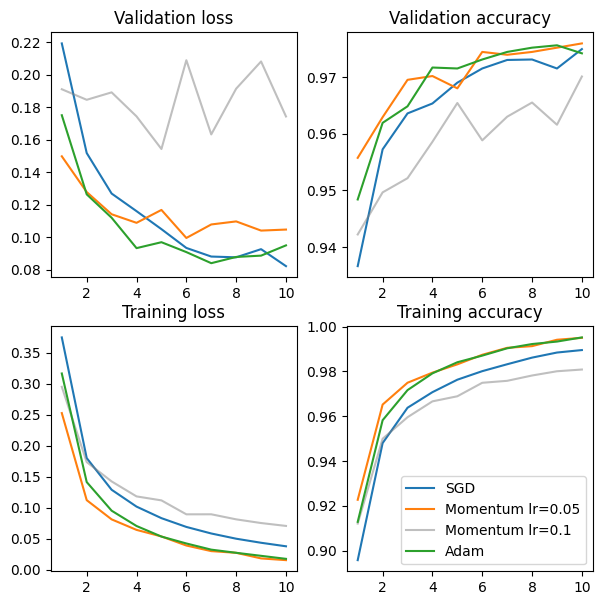

In [ ]:
# Compare learning curves again with the new momentum model
epochs = range(1, 11)

f, ax = plt.subplots(2, 2, figsize=(7, 7))

# Validation loss
ax[0,0].plot(epochs, results_sgd["val_losses"], label="SGD")
ax[0,0].plot(epochs, results_momentum_lower_lr["val_losses"], label="Momentum lr=0.05")
ax[0,0].plot(epochs, results_momentum["val_losses"], label="Momentum lr=0.1", color='grey', alpha=0.5)
ax[0,0].plot(epochs, results_adam["val_losses"], label="Adam")
ax[0,0].set_title("Validation loss")

# Validation accuracy
ax[0,1].plot(epochs, results_sgd["val_accuracies"], label="SGD")
ax[0,1].plot(epochs, results_momentum_lower_lr["val_accuracies"], label="Momentum lr=0.05")
ax[0,1].plot(epochs, results_momentum["val_accuracies"], label="Momentum lr=0.1", color='grey', alpha=0.5)
ax[0,1].plot(epochs, results_adam["val_accuracies"], label="Adam")
ax[0,1].set_title("Validation accuracy")

# Training loss
ax[1,0].plot(epochs, results_sgd["train_losses"], label="SGD")
ax[1,0].plot(epochs, results_momentum_lower_lr["train_losses"], label="Momentum lr=0.05")
ax[1,0].plot(epochs, results_momentum["train_losses"], label="Momentum lr=0.1", color='grey', alpha=0.5)
ax[1,0].plot(epochs, results_adam["train_losses"], label="Adam")
ax[1,0].set_title("Training loss")

# Training accuracy
ax[1,1].plot(epochs, results_sgd["train_accuracies"], label="SGD")
ax[1,1].plot(epochs, results_momentum_lower_lr["train_accuracies"], label="Momentum lr=0.05")
ax[1,1].plot(epochs, results_momentum["train_accuracies"], label="Momentum lr=0.1", color='grey', alpha=0.5)
ax[1,1].plot(epochs, results_adam["train_accuracies"], label="Adam")
ax[1,1].set_title("Training accuracy")
ax[1,1].legend()

plt.show()

### Optimizer behavior

- SGD: slower convergence, but stable
- SGD + momentum: faster and smoother updates when it's tuned well
- Adam: fastest convergence, adapts learning rates automatically

Adam works well by default,
but SGD can generalize better in some cases.

## Training Stability Experiments

We compare:
- good initialization
- bad initialization (zeros)
- very large weights
- ReLU vs Sigmoid

Goal:
understand why initialization and activation matter.

In [ ]:
# Model definitions for activation function comparison
def make_mlp_relu():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)

def make_mlp_sigmoid():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.Sigmoid(),
        nn.Linear(128, 10)
    ).to(device)

In [ ]:
# Train both models and compare results
num_epochs = 10
criterion = nn.CrossEntropyLoss()

In [78]:
# Experiment 1: baseline (good initialization + ReLU)
model_baseline = make_mlp_relu()
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)

results_baseline = train_model(
    model_baseline, optimizer_baseline, criterion, train_loader, val_loader, num_epochs=num_epochs
)

Epoch 1/10 - train loss: 0.3258, acc: 0.9096 - val loss: 0.1853, acc: 0.9479
Epoch 2/10 - train loss: 0.1468, acc: 0.9572 - val loss: 0.1309, acc: 0.9607
Epoch 3/10 - train loss: 0.0986, acc: 0.9706 - val loss: 0.1137, acc: 0.9653
Epoch 4/10 - train loss: 0.0729, acc: 0.9785 - val loss: 0.0969, acc: 0.9708
Epoch 5/10 - train loss: 0.0564, acc: 0.9831 - val loss: 0.0942, acc: 0.9720
Epoch 6/10 - train loss: 0.0451, acc: 0.9865 - val loss: 0.0858, acc: 0.9734
Epoch 7/10 - train loss: 0.0365, acc: 0.9890 - val loss: 0.0941, acc: 0.9735
Epoch 8/10 - train loss: 0.0295, acc: 0.9908 - val loss: 0.0863, acc: 0.9768
Epoch 9/10 - train loss: 0.0221, acc: 0.9934 - val loss: 0.0922, acc: 0.9751
Epoch 10/10 - train loss: 0.0184, acc: 0.9942 - val loss: 0.1004, acc: 0.9750


In [79]:
# Experiment 2: bad initialization (all zeros)
def init_zeros(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.constant_(m.weight, 0.0)
            nn.init.constant_(m.bias, 0.0)

model_bad = make_mlp_relu()
init_zeros(model_bad)

optimizer_bad = torch.optim.Adam(model_bad.parameters(), lr=1e-3)

results_bad = train_model(
    model_bad, optimizer_bad, criterion, train_loader, val_loader, num_epochs=num_epochs
)

Epoch 1/10 - train loss: 2.3015, acc: 0.1108 - val loss: 2.3013, acc: 0.1141
Epoch 2/10 - train loss: 2.3014, acc: 0.1119 - val loss: 2.3014, acc: 0.1141
Epoch 3/10 - train loss: 2.3014, acc: 0.1119 - val loss: 2.3015, acc: 0.1141
Epoch 4/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3013, acc: 0.1141
Epoch 5/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3015, acc: 0.1141
Epoch 6/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3014, acc: 0.1141
Epoch 7/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3014, acc: 0.1141
Epoch 8/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3013, acc: 0.1141
Epoch 9/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3014, acc: 0.1141
Epoch 10/10 - train loss: 2.3013, acc: 0.1119 - val loss: 2.3016, acc: 0.1141


### Why initialization matters

If all weights are initialized to zero:
→ all neurons learn the same thing (symmetry problem)
→ the model cannot learn meaningful features

Proper random initialization breaks symmetry
and allows different neurons to specialize.

In [80]:
# Experiment 3: too large initialization
def init_large(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=5.0)
            nn.init.constant_(m.bias, 0.0)

model_large = make_mlp_relu()
init_large(model_large)

optimizer_large = torch.optim.Adam(model_large.parameters(), lr=1e-3)

results_large = train_model(
    model_large, optimizer_large, criterion, train_loader, val_loader, num_epochs=num_epochs
)

Epoch 1/10 - train loss: 780.7585, acc: 0.3921 - val loss: 309.4076, acc: 0.6108
Epoch 2/10 - train loss: 225.7297, acc: 0.6939 - val loss: 171.6120, acc: 0.7473
Epoch 3/10 - train loss: 144.4906, acc: 0.7780 - val loss: 123.2666, acc: 0.8041
Epoch 4/10 - train loss: 108.0988, acc: 0.8202 - val loss: 99.1279, acc: 0.8349
Epoch 5/10 - train loss: 86.5540, acc: 0.8451 - val loss: 83.4045, acc: 0.8529
Epoch 6/10 - train loss: 72.1883, acc: 0.8629 - val loss: 73.3131, acc: 0.8632
Epoch 7/10 - train loss: 61.6995, acc: 0.8754 - val loss: 64.9004, acc: 0.8723
Epoch 8/10 - train loss: 53.7742, acc: 0.8860 - val loss: 58.6052, acc: 0.8791
Epoch 9/10 - train loss: 47.4993, acc: 0.8945 - val loss: 53.8614, acc: 0.8847
Epoch 10/10 - train loss: 42.3651, acc: 0.9020 - val loss: 49.6508, acc: 0.8900


### Effect of large weights

Very large initial weights can lead to:
- unstable activations
- exploding gradients

This makes training difficult or unstable.

Good initialization keeps values in a reasonable range.

In [81]:
# Experiment 4: sigmoid vs ReLU
model_sigmoid = make_mlp_sigmoid()
optimizer_sigmoid = torch.optim.Adam(model_sigmoid.parameters(), lr=1e-3)

results_sigmoid = train_model(
    model_sigmoid, optimizer_sigmoid, criterion, train_loader, val_loader, num_epochs=num_epochs
)

Epoch 1/10 - train loss: 0.4823, acc: 0.8796 - val loss: 0.2511, acc: 0.9272
Epoch 2/10 - train loss: 0.2144, acc: 0.9385 - val loss: 0.1893, acc: 0.9447
Epoch 3/10 - train loss: 0.1597, acc: 0.9545 - val loss: 0.1514, acc: 0.9550
Epoch 4/10 - train loss: 0.1251, acc: 0.9643 - val loss: 0.1304, acc: 0.9617
Epoch 5/10 - train loss: 0.1015, acc: 0.9713 - val loss: 0.1146, acc: 0.9654
Epoch 6/10 - train loss: 0.0839, acc: 0.9763 - val loss: 0.1094, acc: 0.9675
Epoch 7/10 - train loss: 0.0703, acc: 0.9806 - val loss: 0.0978, acc: 0.9715
Epoch 8/10 - train loss: 0.0597, acc: 0.9840 - val loss: 0.0907, acc: 0.9723
Epoch 9/10 - train loss: 0.0503, acc: 0.9869 - val loss: 0.0913, acc: 0.9728
Epoch 10/10 - train loss: 0.0424, acc: 0.9892 - val loss: 0.0861, acc: 0.9734


### Vanishing gradients

Sigmoid squashes values between 0 and 1.

Its gradients become very small for large inputs:
→ gradients vanish
→ learning slows down

ReLU avoids this problem:
→ stable gradients
→ faster training

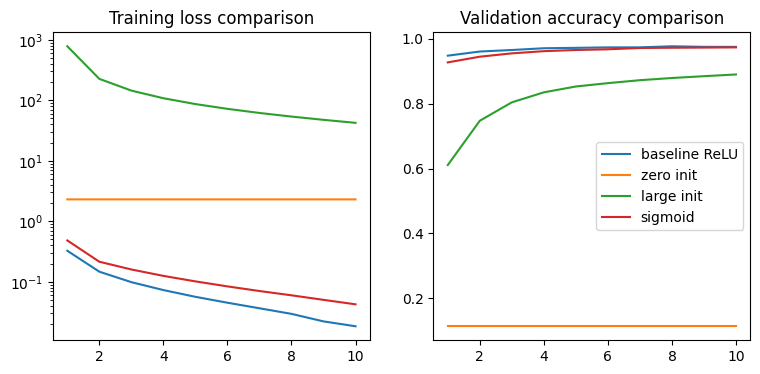

In [ ]:
# Visualize training and validation loss and accuracy over epochs for all experiments
epochs = range(1, num_epochs + 1)

f, ax = plt.subplots(1,2,figsize=(9,4))
ax[0].plot(epochs, results_baseline["train_losses"], label="baseline ReLU")
ax[0].plot(epochs, results_bad["train_losses"], label="zero init")
ax[0].plot(epochs, results_large["train_losses"], label="large init")
ax[0].plot(epochs, results_sigmoid["train_losses"], label="sigmoid")
# ax[0].set_ylim([0, 1])
ax[0].set_yscale("log") # log scale to see small differences better
ax[0].set_title("Training loss comparison")

ax[1].plot(epochs, results_baseline["val_accuracies"], label="baseline ReLU")
ax[1].plot(epochs, results_bad["val_accuracies"], label="zero init")
ax[1].plot(epochs, results_large["val_accuracies"], label="large init")
ax[1].plot(epochs, results_sigmoid["val_accuracies"], label="sigmoid")
ax[1].set_title("Validation accuracy comparison")
ax[1].legend()

plt.show()

- Bad initialization → no learning (symmetry problem)
- Large weights → unstable gradients
- Sigmoid → vanishing gradients
- ReLU → stable training

## Final Conclusions

- Neural networks require proper:
  - initialization
  - activation functions
  - optimization

- ReLU + Adam provides strong default performance

- Regularization (dropout, weight decay) helps prevent overfitting

- Training curves are essential to diagnose:
  - convergence
  - instability
  - overfitting